k = 1.0

  h = 0.01
  eigenvalues : (1+0.010000000000000002j),  (1-0.010000000000000002j)
  max eigenvalues : 1.0000499987500624
  Solution may not be Entirely Stable ;)

  h = 0.02
  eigenvalues : (1+0.02j),  (1-0.02j)
  max eigenvalues : 1.000199980003999
  Solution may not be Entirely Stable ;)

  h = 0.03
  eigenvalues : (1+0.03j),  (1-0.03j)
  max eigenvalues : 1.0004498987955368
  Solution may not be Entirely Stable ;)

  h = 0.05
  eigenvalues : (1+0.049999999999999996j),  (1-0.049999999999999996j)
  max eigenvalues : 1.0012492197250393
  Solution may not be Entirely Stable ;)

  h = 0.1
  eigenvalues : (1+0.1j),  (1-0.1j)
  max eigenvalues : 1.004987562112089
  Solution may not be Entirely Stable ;)

  h = 0.2
  eigenvalues : (1+0.19999999999999998j),  (1-0.19999999999999998j)
  max eigenvalues : 1.019803902718557
  Solution may not be Entirely Stable ;)

  h = 0.3
  eigenvalues : (1+0.29999999999999993j),  (1-0.29999999999999993j)
  max eigenvalues : 1.0440306508910548
  Solut

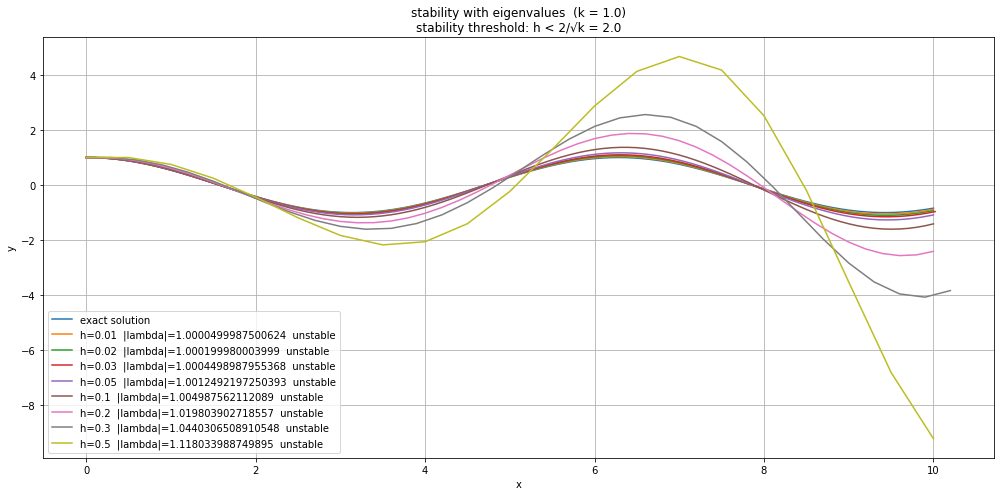

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
k       = 1.0
x_start = 0
x_end   = 10
y_0     = 1.0
v_0     = 0.0

h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

# exact solution for reference
x_exact = np.linspace(x_start, x_end, 2000)
y_exact = np.cos(np.sqrt(k) * x_exact)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(x_exact, y_exact, label='exact solution')

print(f"k = 1.0")

for h in h_values:

    A = np.array([[1,      h  ],
                  [-h * k, 1  ]])

    eigenvalues = np.linalg.eigvals(A)
    max_magnitude = np.max(np.abs(eigenvalues))

    stable = max_magnitude < 1.0
    if stable:
        verdict = "Solution is Stable"
    else:
        verdict = "Solution may not be Entirely Stable ;)"

    print(f"\n  h = {h}")
    print(f"  eigenvalues : {eigenvalues[0]},  {eigenvalues[1]}")
    print(f"  max eigenvalues : {max_magnitude}")
    print(f"  {verdict}")

    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(x_values)):
        state      = np.array([y_values[i - 1], v_values[i - 1]])
        new_state  = A @ state
        y_values[i] = new_state[0]
        v_values[i] = new_state[1]

    if stable:
        label = f"h={h}  |lambda|={max_magnitude}  {'stable'}"
    else:
        label = label = f"h={h}  |lambda|={max_magnitude}  {'unstable'}"

    ax.plot(x_values, y_values, label=label)

print(f"  stability threshold:  h < 2/√k = {2/np.sqrt(k):.4f}")

ax.set_title(
    f"stability with eigenvalues  (k = {k})\n"
    f"stability threshold: h < 2/√k = {2/np.sqrt(k):.1f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()